# Global Parameters and Database Initialization

In [3]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# DB_PATH = "../../datasets/CCSMLDatabase.db"
DB_PATH = "/Users/ryannguyen/Desktop/CCSBase/CCSMLDatabase.db"
TABLE = "master_clean"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(
    f"SELECT * FROM master_clean",
    conn,
)
conn.close()

# Global style settings
plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 3,               # Thicker axis lines
    "axes.spines.top": True,            # Remove top spine
    "axes.spines.right": True,          # Remove right spine
    "xtick.major.width": 3,            # Match tick thickness to axis
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "ytick.major.width": 3,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.labelweight": "normal",
})

n = df.shape[0] 
df.columns

Index(['id', 'tag', 'name', 'pubchemId', 'adduct', 'mass', 'z', 'ccs', 'smi',
       'inchikey', 'superclass', 'class', 'subclass'],
      dtype='object')

# Train and Tes Set Subclass Distribution

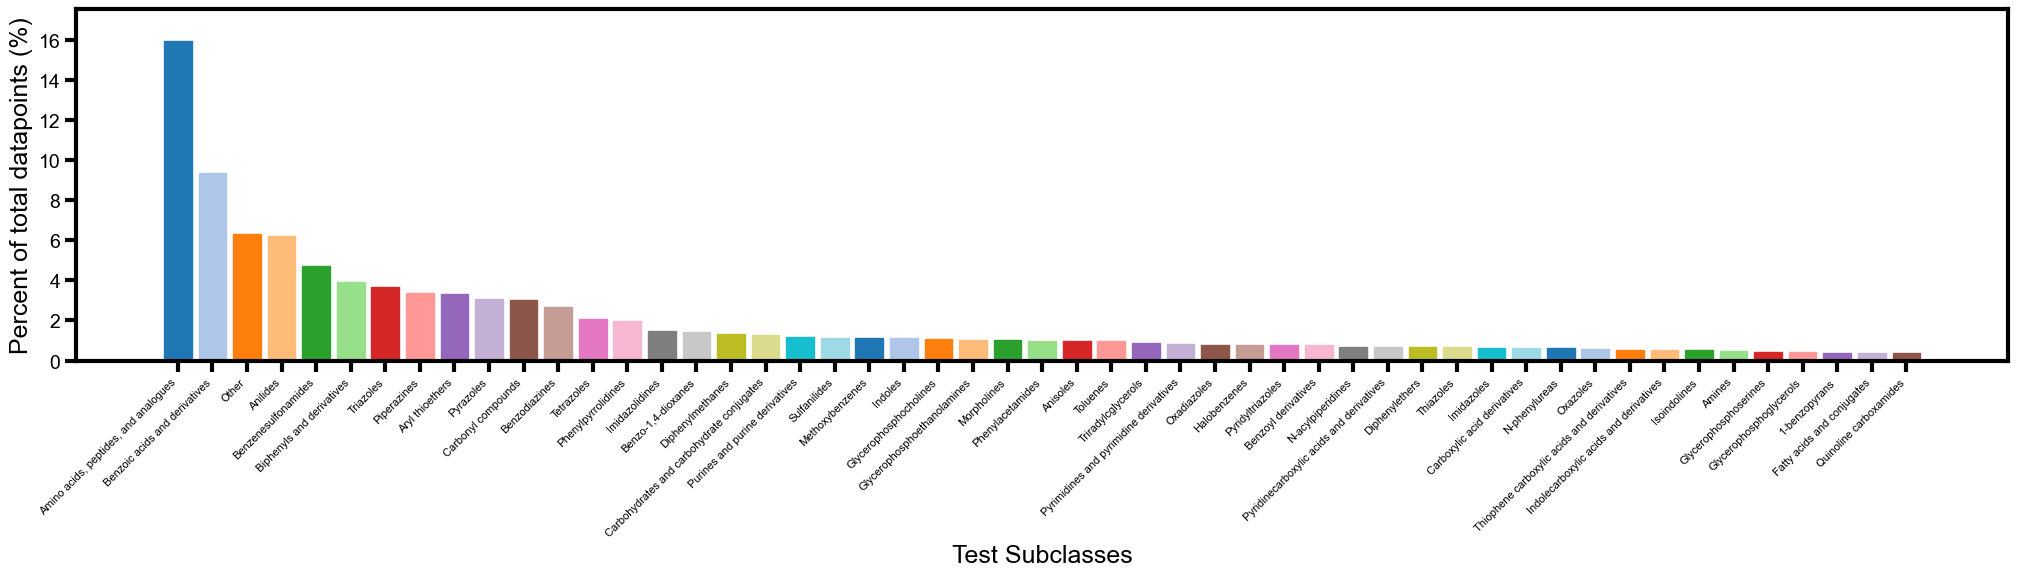

Top 10 subclasses:
Amino acids, peptides, and analogues: 15.94%
Benzoic acids and derivatives: 9.34%
Anilides: 6.21%
Benzenesulfonamides: 4.74%
Biphenyls and derivatives: 3.93%
Triazoles: 3.65%
Piperazines: 3.40%
Aryl thioethers: 3.34%
Pyrazoles: 3.08%
Carbonyl compounds: 3.03%


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

train = False
csvfile = "train_data.csv" if train else "test_data.csv"
title = "Training Subclasses" if train else "Test Subclasses"

df = pd.read_csv(f"/Users/ryannguyen/Desktop/ccsbase2/pretrained/{csvfile}")

counts_all = df["subclass"].value_counts()
top = counts_all.head(50)
other = counts_all.iloc[50:].sum()

counts = pd.concat([top, pd.Series({"Other": other})]).sort_values(ascending=False)

perc = (counts / counts.sum()) * 100

plt.figure(figsize=(max(8, 0.4 * len(perc)), 6))
bars = plt.bar(perc.index, perc.values)

for i, bar in enumerate(bars):
    bar.set_color(plt.cm.tab20(i % 20))

plt.ylabel("Percent of total datapoints (%)")
plt.xlabel(title)

plt.ylim(0, perc.max() * 1.1)
plt.xticks(rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

top10 = counts_all.head(10)
top10_perc = (top10 / counts_all.sum()) * 100

print("Top 10 subclasses:")
for subclass, pct in top10_perc.items():
    print(f"{subclass}: {pct:.2f}%")

# Training and Test Set Histograms

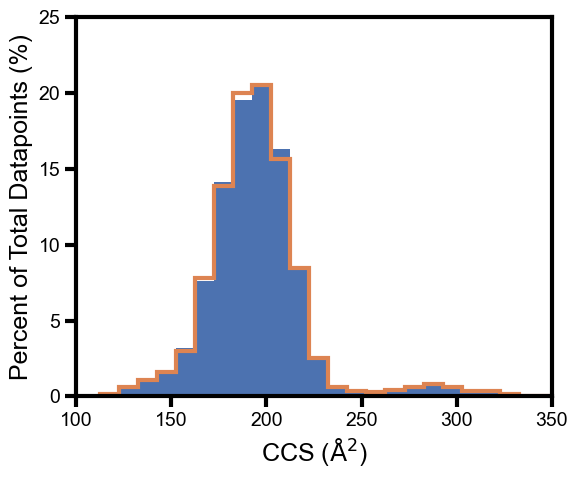

In [6]:
# Path to csv files 
csv_a = "/Users/ryannguyen/Desktop/ccsbase2/pretrained/train_data.csv"         
csv_b = "/Users/ryannguyen/Desktop/ccsbase2/pretrained/test_data.csv" 
# Column name
COL = "ccs"

# Load files 
df_a = pd.read_csv(csv_a)
df_b = pd.read_csv(csv_b)

ccs_a = df_a[COL].dropna().to_numpy()
ccs_b = df_b[COL].dropna().to_numpy()

# Shared 10 Å^2 bins spanning both datasets
bin_width = 10
lo = min(ccs_a.min(), ccs_b.min())
hi = max(ccs_a.max(), ccs_b.max())
bins = np.arange(lo, hi + bin_width, bin_width)

# Percent weights (each histogram sums to 100%)
w_a = np.ones_like(ccs_a) / len(ccs_a) * 100
w_b = np.ones_like(ccs_b) / len(ccs_b) * 100

fig, ax = plt.subplots(figsize=(6, 5))


ax.hist(
    ccs_a,
    bins=bins,
    weights=w_a,
    color="#4C72B0",
    # alpha=0.7,
    rwidth=1.0,
    edgecolor="none",
    label="train_data"
) 
ax.hist(
    ccs_b,
    bins=bins,
    weights=w_b,
    histtype="step",
    linewidth=3.0,
    color="#DD8452",
    label="training"
)

ax.set_xlabel("CCS ($\mathrm{\AA^2}$)")
ax.set_ylabel("Percent of Total Datapoints (%)")
ax.set_xlim(100, 350)
ax.set_ylim(0, 25)

# ax.legend(frameon=False)
plt.tight_layout()

plt.savefig(
    "Train_Test_Histogram.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# PCA 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sys
from pathlib import Path

from utils import Utils  # adjust if needed


train = False
csvfile = "/Users/ryannguyen/Desktop/ccsbase2/pretrained/train_data.csv" if train else "/Users/ryannguyen/Desktop/CCSBase2/test_data.csv"
title = "Training PCA" if train else "Test PCA"
df = pd.read_csv(csvfile)


# adduct vocabulary (from this split only)
adducts = sorted(df["adduct"].unique().tolist())

# compute descriptors
u = Utils()
X = np.vstack([
    u.calculate_descriptors(
        row["smi"], row["mass"], row["z"], adducts, row["adduct"]
    )
    for _, row in df.iterrows()
])

# scale + PCA
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_s)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# color by subclass (no legend)
colors = df["subclass"].astype("category").cat.codes

# plot (4-quadrant style)
plt.figure(figsize=(6, 5))
plt.scatter(
    Z[:, 0],
    Z[:, 1],
    c=colors,
    cmap=plt.cm.tab20,
    s=14,
    alpha=0.5,
    linewidths=0,
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel(f"PC1 ({var1:.1f} %)")
plt.ylabel(f"PC2 ({var2:.1f} %)")
# plt.title(title)

ax = plt.gca()
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.set_xlim(-10, 40)
ax.set_ylim(-10, 60)

plt.tight_layout()
plt.savefig(
    "Train_PCA.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

ModuleNotFoundError: No module named 'utils'